In [1]:
import sys

# Add parent directory to path for imports
#sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
#sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

In [2]:
# Add parent directory to path for imports
#sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')

from tdmpc2.common.causal_gradient import (
    LatentObjectiveRunner,
    BackpropGradientProbe,
)

In [3]:
def load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    cart_position_list = to_list(cart_position)
    pole_angle_list = to_list(pole_angle)
    seed_list = to_list(seed)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        inital_state = config.get('initial_state')
        # Check each criterion
        if cart_position_list is not None and inital_state[
                0] not in cart_position_list:
            continue
        if pole_angle_list is not None and inital_state[
                1] not in pole_angle_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


In [4]:
def load_sweep_metadata(sweep_base_dir):
    """
    Loads and flattens metadata for all sweeps in the given base directory.

    Args:
        sweep_base_dir (str or Path): Root directory containing sweep subdirs.

    Returns:
        pd.DataFrame: DataFrame of flattened episode metadata for each run.
    """
    sweep_base_dir = Path(sweep_base_dir)
    all_metadata = []
    for sweep_dir in sweep_base_dir.iterdir():
        if sweep_dir.is_dir():
            metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
            if metadata_path.exists():
                with open(metadata_path, 'r') as f:
                    metadata = json.load(f)
                    # Flatten the nested metadata dictionary
                    flattened_metadata = flatten_dict(metadata)
                    # Add the directory path
                    flattened_metadata['directory'] = str(sweep_dir)
                    all_metadata.append(flattened_metadata)

    print(f"Found {len(all_metadata)} configurations")
    # Create DataFrame from flattened metadata
    df_metadata = pd.DataFrame(all_metadata)
    return df_metadata


# Example usage:
df_metadata = load_sweep_metadata(
    sweep_base_dir="logs/28112025-initial_conditions_seeds_sweep")


Found 165 configurations


In [5]:
df = load_data(df_metadata, cart_position=0.)

Found 55 configurations


100%|██████████| 55/55 [00:00<00:00, 200.91it/s]


In [6]:
obs = np.concatenate(df['observations'].tolist())

z = np.concatenate(df['latent_states'].tolist())
z.shape, obs.shape

((27500, 512), (27500, 5))

In [7]:
# varsname_dict = {
#     0: 'cart position',
#     1: 'cos(pole angle)',
#     2: 'sin(pole angle)',
#     3: 'cart velocity',
#     4: 'pole angular velocity',
# }


In [8]:
# Select observations where abs(theta_dot) < threshold and cos(theta) > 0 (small tilts)
threshold = 0.1

cos_theta = obs[:, 1]
theta_dot = obs[:, 4]

# Boolean mask: abs(theta_dot) < threshold and cos(theta) > 0
mask = (np.abs(theta_dot) < threshold) & (cos_theta > 0)

# Select observations and corresponding latents
obs_small_tilt = obs[mask]
z_small_tilt = z[mask]


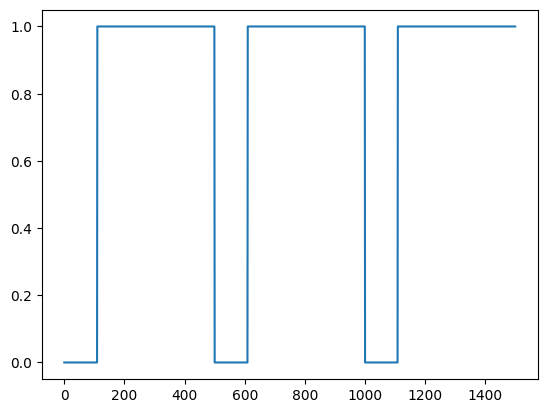

In [9]:
plt.plot(mask[:1500])

## Train linear and nonlinear decoder

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Prepare train/val splits
latent_dim = z.shape[1]
obs_dim = obs.shape[1]

X = torch.from_numpy(z).float()
y = torch.from_numpy(obs).float()

X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=42)


100%|██████████| 600/600 [00:04<00:00, 124.89it/s]


Linear Model R2 (train): 0.9853
Linear Model R2 (val):   0.9878


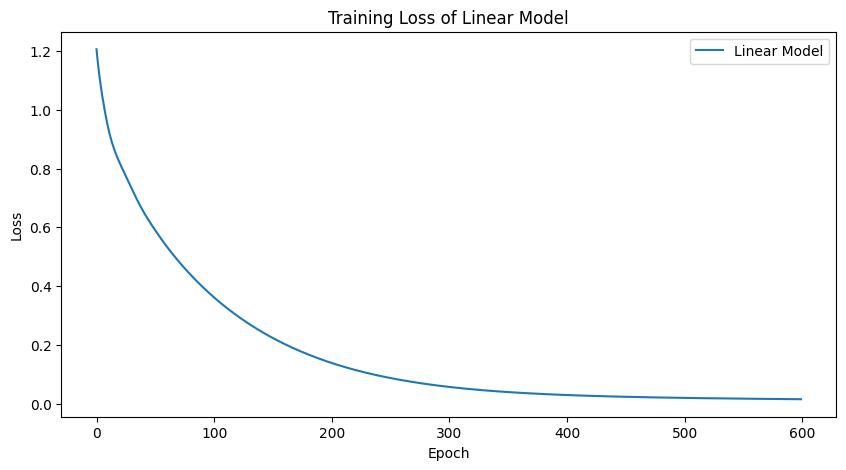

100%|██████████| 600/600 [00:41<00:00, 14.42it/s]


Nonlinear Model R2 (train): 0.9995
Nonlinear Model R2 (val):   0.9995


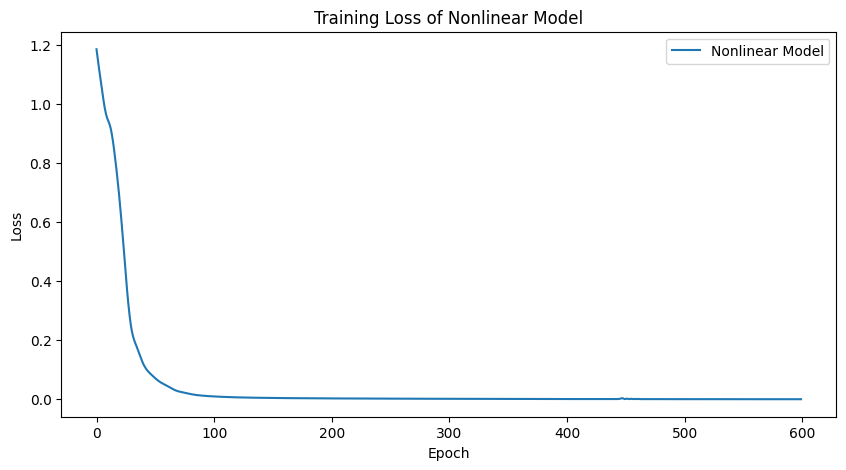

In [11]:
# ----------- Linear Model -----------
class LinearModel(nn.Module):

    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)


linear_model = LinearModel(latent_dim, obs_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(linear_model.parameters(), lr=1e-3)

# Training loop for linear model
n_epochs_lin = 600
losses_lin = []
for epoch in tqdm(range(n_epochs_lin)):
    linear_model.train()
    optimizer.zero_grad()
    y_pred = linear_model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    losses_lin.append(loss.item())
# Eval linear model
linear_model.eval()
with torch.no_grad():
    y_pred_train_lin = linear_model(X_train).cpu().numpy()
    y_pred_val_lin = linear_model(X_val).cpu().numpy()
    y_train_np = y_train.cpu().numpy()
    y_val_np = y_val.cpu().numpy()

r2_train_lin = r2_score(y_train_np,
                        y_pred_train_lin,
                        multioutput='variance_weighted')
r2_val_lin = r2_score(y_val_np, y_pred_val_lin, multioutput='variance_weighted')

print(f"Linear Model R2 (train): {r2_train_lin:.4f}")
print(f"Linear Model R2 (val):   {r2_val_lin:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(losses_lin, label='Linear Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss of Linear Model')
plt.legend()
plt.show()


# ----------- Nonlinear Model -----------
class NonlinearModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, act='ReLU'):
        super().__init__()
        act_fn = nn.ReLU if act == 'ReLU' else nn.SiLU
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), act_fn(),
                                 nn.Linear(hidden_dim, hidden_dim), act_fn(),
                                 nn.Linear(hidden_dim, output_dim))

    def forward(self, x):
        return self.net(x)


nonlin_model = NonlinearModel(latent_dim, 128, obs_dim, act='SiLU')
criterion_nl = nn.MSELoss()
optimizer_nl = optim.Adam(nonlin_model.parameters(), lr=1e-3)

# Training loop for nonlinear model
n_epochs_nl = 600
losses_nl = []
for epoch in tqdm(range(n_epochs_nl)):
    nonlin_model.train()
    optimizer_nl.zero_grad()
    y_pred = nonlin_model(X_train)
    loss = criterion_nl(y_pred, y_train)
    loss.backward()
    optimizer_nl.step()
    losses_nl.append(loss.item())

# Eval nonlinear model
nonlin_model.eval()
with torch.no_grad():
    y_pred_train_nl = nonlin_model(X_train).cpu().numpy()
    y_pred_val_nl = nonlin_model(X_val).cpu().numpy()

r2_train_nl = r2_score(y_train_np,
                       y_pred_train_nl,
                       multioutput='variance_weighted')
r2_val_nl = r2_score(y_val_np, y_pred_val_nl, multioutput='variance_weighted')

print(f"Nonlinear Model R2 (train): {r2_train_nl:.4f}")
print(f"Nonlinear Model R2 (val):   {r2_val_nl:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(losses_nl, label='Nonlinear Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss of Nonlinear Model')
plt.legend()
plt.show()

## Estimate gradient

In [12]:
# Define decoder to extract cart position from latent
def decoder(z):
    decoded = nonlin_model(z)
    return decoded


def objective(state):
    cart_pos = state[0]
    return cart_pos


# Define decoder to extract cart position from latent
def decoder_nonlinear(z):
    decoded = nonlin_model(z)
    return decoded


def decoder_linear(z):
    decoded = linear_model(z)
    return decoded


# Create runner and probe
latent_runner_linear = LatentObjectiveRunner(
    objective=objective,
    decoder=decoder_linear,
    track_gradients=True,  # Enable backprop
)

latent_runner_nonlinear = LatentObjectiveRunner(
    objective=objective,
    decoder=decoder_nonlinear,
    track_gradients=True,  # Enable backprop
)

probe_linear = BackpropGradientProbe(objective_runner=latent_runner_linear,)
probe_nonlinear = BackpropGradientProbe(
    objective_runner=latent_runner_nonlinear,)

In [13]:
z_small_tilt.shape

(21628, 512)

In [14]:
results_linear = []
results_nonlinear = []
for _z in tqdm(z_small_tilt):
    _z = torch.tensor(_z, requires_grad=True)
    gradient_linear, result_linear = probe_linear.estimate(_z)
    gradient_nonlinear, result_nonlinear = probe_nonlinear.estimate(_z)
    results_linear.append((gradient_linear, result_linear))
    results_nonlinear.append((gradient_nonlinear, result_nonlinear))

100%|██████████| 21628/21628 [00:11<00:00, 1943.22it/s]


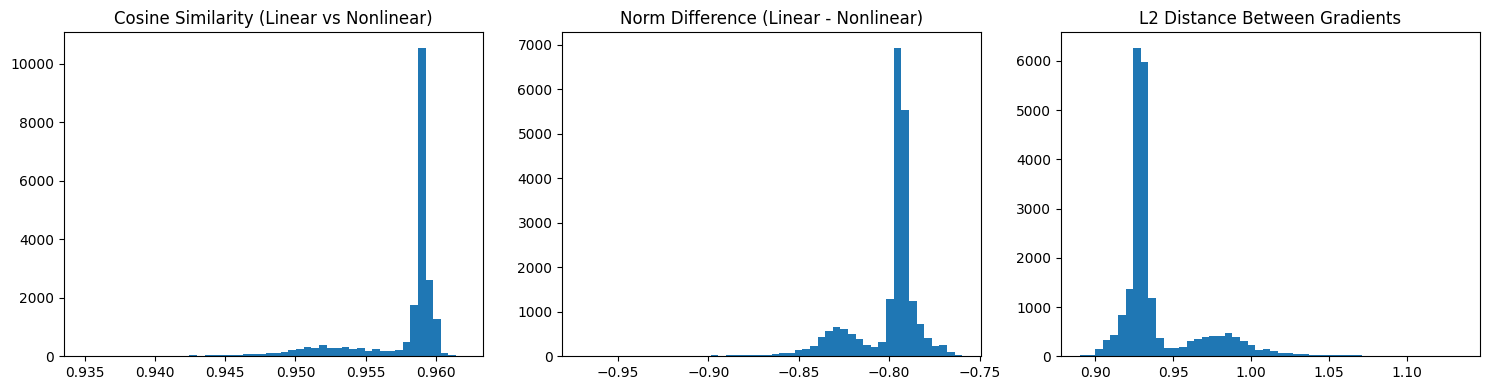

Cosine similarity: mean=0.9575, std=0.0034
Norm diff: mean=-0.8007, std=0.0194
L2 dist: mean=0.9402, std=0.0276


In [15]:
import torch.nn.functional as F

# Compute cosine similarity between the gradients for every z
cosine_similarities = []
grad_norm_diffs = []
grad_l2_dists = []

for (grad_linear, _), (grad_nonlinear, _) in zip(results_linear,
                                                 results_nonlinear):
    # grads are tensors, ensure shape
    sim = F.cosine_similarity(grad_linear.unsqueeze(0),
                              grad_nonlinear.unsqueeze(0)).item()
    cosine_similarities.append(sim)
    # norm difference
    grad_norm_diffs.append(
        torch.linalg.norm(grad_linear).item() -
        torch.linalg.norm(grad_nonlinear).item())
    # l2 distance between gradients
    grad_l2_dists.append(torch.linalg.norm(grad_linear - grad_nonlinear).item())

cosine_similarities = np.array(cosine_similarities)
grad_norm_diffs = np.array(grad_norm_diffs)
grad_l2_dists = np.array(grad_l2_dists)

# Analysis plots
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(cosine_similarities, bins=50)
plt.title("Cosine Similarity (Linear vs Nonlinear)")

plt.subplot(1, 3, 2)
plt.hist(grad_norm_diffs, bins=50)
plt.title("Norm Difference (Linear - Nonlinear)")

plt.subplot(1, 3, 3)
plt.hist(grad_l2_dists, bins=50)
plt.title("L2 Distance Between Gradients")

plt.tight_layout()
plt.show()

# Summary statistics
print(
    f"Cosine similarity: mean={cosine_similarities.mean():.4f}, std={cosine_similarities.std():.4f}"
)
print(
    f"Norm diff: mean={grad_norm_diffs.mean():.4f}, std={grad_norm_diffs.std():.4f}"
)
print(
    f"L2 dist: mean={grad_l2_dists.mean():.4f}, std={grad_l2_dists.std():.4f}")

Total linear gradients: 21628


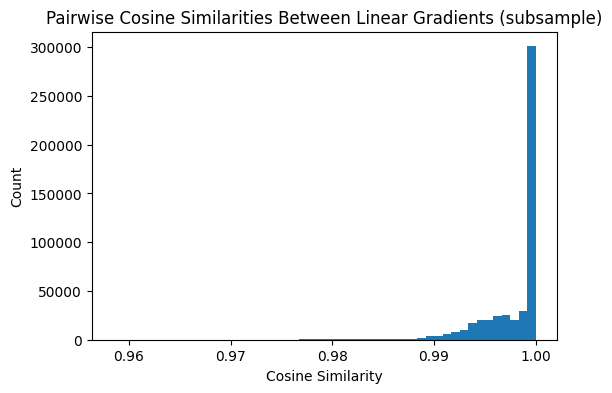

Mean cosine similarity: 0.9980
Stddev cosine similarity: 0.0033
Min: 0.9584   Max: 1.0000


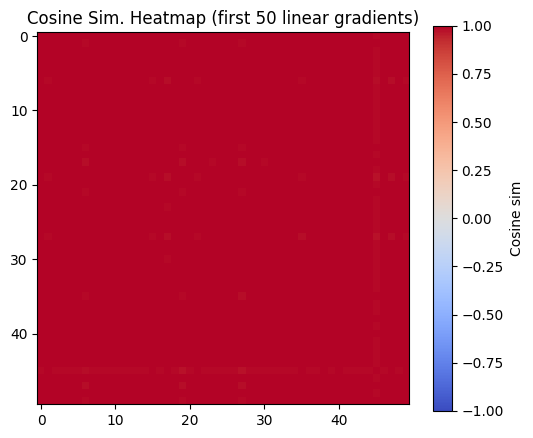

In [16]:
# Analyze similarities between linear gradients
# We'll subsample to keep compute+visualization reasonable

# Extract gradients from results_linear (first element of each tuple)
all_linear_grads = [g for (g, _) in results_nonlinear]

# Number of gradients
n_linear_grads = len(all_linear_grads)
print(f"Total linear gradients: {n_linear_grads}")

# Subsample 1000 random gradients for pairwise comparison
subsample_size = 1000
np.random.seed(0)
subsample_idxs = np.random.choice(n_linear_grads,
                                  size=subsample_size,
                                  replace=False)
subsample_grads = [all_linear_grads[i] for i in subsample_idxs]

# Stack into a matrix (each row is one flattened gradient)
grad_matrix = torch.stack([g.flatten() for g in subsample_grads])

# Compute cosine similarity matrix (1000 x 1000)
# Normalize each gradient
grad_matrix_norm = grad_matrix / grad_matrix.norm(dim=1, keepdim=True)
cos_sim_matrix = grad_matrix_norm @ grad_matrix_norm.T
cos_sim_matrix = cos_sim_matrix.cpu().numpy()

# Keep only upper triangular (excluding diagonal) for summary
tri_idx = np.triu_indices(subsample_size, k=1)
cosine_sims = cos_sim_matrix[tri_idx]

plt.figure(figsize=(6, 4))
plt.hist(cosine_sims, bins=50)
plt.title("Pairwise Cosine Similarities Between Linear Gradients (subsample)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.show()

print(f"Mean cosine similarity: {cosine_sims.mean():.4f}")
print(f"Stddev cosine similarity: {cosine_sims.std():.4f}")
print(f"Min: {cosine_sims.min():.4f}   Max: {cosine_sims.max():.4f}")

# Optionally, show a heatmap of a small portion of the matrix
plt.figure(figsize=(6, 5))
plt.imshow(cos_sim_matrix[:50, :50], vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label='Cosine sim')
plt.title("Cosine Sim. Heatmap (first 50 linear gradients)")
plt.show()


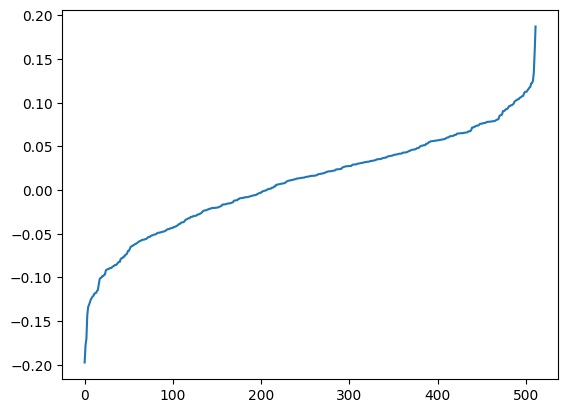

In [17]:
# Order the gradient and plot
ordered_grad = torch.sort(gradient_linear)[0]
plt.plot(ordered_grad)

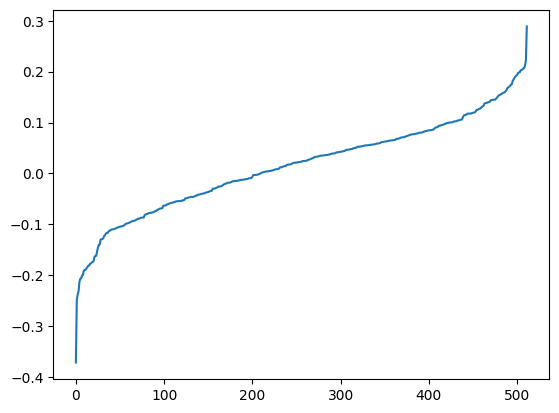

In [18]:
# Order the gradient and plot
ordered_grad = torch.sort(gradient_nonlinear)[0]
plt.plot(ordered_grad)

In [20]:
# Save the linear and nonlinear decoders as .pt files

decoder_linear_path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/281125-latent_intervention_control/decoder_linear.pt"
decoder_nonlinear_path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/281125-latent_intervention_control/decoder_nonlinear.pt"

torch.save(linear_model.state_dict(), decoder_linear_path)
torch.save(nonlin_model.state_dict(), decoder_nonlinear_path)


In [19]:
# Save gradient_linear and gradient_nonlinear as .npy files

path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/281125-latent_intervention_control/"
np.save(path + "backprop_gradient_linear_position.npy",
        gradient_linear.cpu().numpy())
np.save(path + "backprop_gradient_nonlinear_position.npy",
        gradient_nonlinear.cpu().numpy())

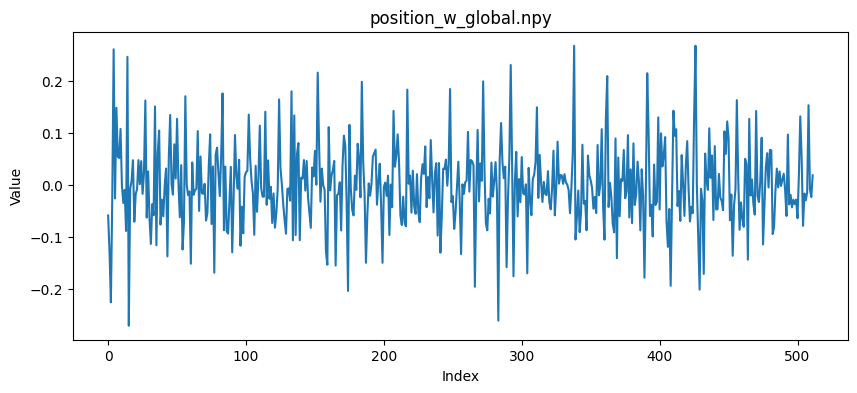

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Load the .npy file
position_w_global = np.load(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/281125-latent_intervention_control/position_w_global_no_theta.npy"
)

# Plot the array
plt.figure(figsize=(10, 4))
plt.plot(position_w_global)
plt.title("position_w_global.npy")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()


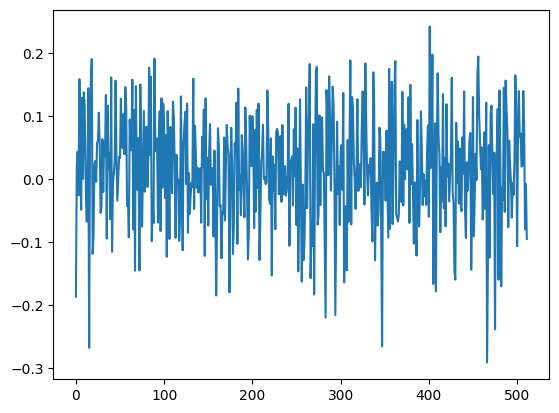

In [21]:
plt.plot(gradient_nonlinear)

In [22]:
F.cosine_similarity(grad_nonlinear.unsqueeze(0),
                    torch.tensor(position_w_global).unsqueeze(0)).item()

0.48796629905700684